# CUADERNO 3: MODELADO DE MACHINE LEARNING
## Entornos de Aprendizaje y Predicción para la Alerta Temprana Académica

**Bootcamp:** Talento Tech Colombia - Bootcamp de Ciencia de Datos  
**Proyecto:** Sistema de Alerta Temprana Académica basado en Machine Learning, aplicando la normativa del sistema educativo colombiano respecto al SIEE.
  
**Autores:** JHOAN FERNANDO ESCOBAR,
             MAURICIO BAENA GIRALDO  

**Metodología:** CRISP-ML (Cross-Industry Standard Process for Machine Learning)  
**Normativa:** Conforme al Sistema Institucional de Evaluación de Estudiantes (SIEE) de Colombia

---

### 🎓 Introducción y Enfoque Pedagógico
¡Hola! Te damos la bienvenida a este cuaderno de **Modelado y Evaluación**.

En las fases anteriores (ETL y EDA), limpiamos la data de **10 años de historia académica (2015-2024)** y descubrimos qué variables influyen en el rendimiento de los estudiantes. En este cuaderno desarrollaremos el núcleo inteligente del proyecto:
1. **Regresión Lineal:** Estimaremos el promedio académico general del estudiante (un número continuo entre 0.0 y 5.0).
2. **Regresión Logística:** Clasificaremos si un estudiante aprueba o reprueba el ciclo escolar (una categoría binaria: 1 = Promovido, 0 = No Promovido).
3. **Árbol de Decisión:** Generaremos reglas lógicas visuales para clasificar la promoción escolar de forma interpretable.

Para cada modelo seguiremos un proceso pedagógico de tres pasos: **Concepto Teórico (con analogías), Ejemplo de Código y Aplicación Práctica con Métricas.**


## Paso 1: Configuración Inicial e Importación de Librerías
Para comenzar, instalamos e importamos las librerías necesarias. Si estás ejecutando este cuaderno en **Google Colab**, las librerías principales ya vienen preinstaladas. Solo importaremos los submódulos de **Scikit-Learn** para Machine Learning, **Pandas** para manejo de datos, y **Plotly/Seaborn** para las visualizaciones.

> 🔍 **Término Clave:** *Scikit-Learn (sklearn)* es la librería estándar de Python para Machine Learning. Contiene herramientas eficientes para minería y análisis de datos, incluyendo algoritmos de regresión, clasificación y preprocesamiento.


In [ ]:
# 1. Configuración de Google Colab (Descomentar si se ejecuta en Colab)
# from google.colab import drive
# drive.mount('/content/drive')

# 2. Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore') # Ocultar advertencias para mantener el cuaderno limpio

# 3. Módulos de Scikit-Learn para preparación y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

print('¡Librerías importadas correctamente!')


¡Librerías importadas correctamente!


## Paso 2: Carga de los Datasets Preparados
En el script de ingeniería de datos (`preparar_datos_y_modelos.py`), creamos un archivo unificado en Excel (`dataset_modelos_aprendizaje.xlsx`) con tres hojas separadas, así como archivos CSV independientes para cada modelo. Esto nos permite tener la data limpia, imputada y ajustada para cada modelo específico.

Vamos a cargar los tres datasets independientes desde los archivos CSV locales.


In [ ]:
# Si estás en Google Colab, define la ruta de tu Drive. Ejemplo:
# RUTA_DIR = '/content/drive/MyDrive/ProyectoML/'
RUTA_DIR = '' # Vacío si los archivos están en el mismo directorio de ejecución

# Cargar datasets para cada modelo
df_lr = pd.read_csv(os.path.join(RUTA_DIR, 'dataset_regresion_lineal.csv'))
df_log = pd.read_csv(os.path.join(RUTA_DIR, 'dataset_regresion_logistica.csv'))
df_dt = pd.read_csv(os.path.join(RUTA_DIR, 'dataset_arboles_decision.csv'))

# Imprimir dimensiones para verificar la carga
print(f'Dimensiones Dataset Regresión Lineal: {df_lr.shape}')
print(f'Dimensiones Dataset Regresión Logística: {df_log.shape}')
print(f'Dimensiones Dataset Árboles de Decisión: {df_dt.shape}')


Dimensiones Dataset Regresión Lineal: (5341, 34)
Dimensiones Dataset Regresión Logística: (5341, 36)
Dimensiones Dataset Árboles de Decisión: (5341, 38)


## Paso 3: Modelo 1 - Regresión Lineal (Predicción de Notas Continuas)

### 🧠 3.1 Concepto Teórico y Analogía
La **Regresión Lineal** busca encontrar la relación matemática entre variables explicativas (características como inasistencias, grado, etc.) y una variable cuantitativa continua (en nuestro caso, el **promedio_nota** de 0.0 a 5.0).

> 💡 **Analogía Práctica:** Imagina que quieres calcular la nota promedio de un estudiante. Sabes que cada falta le resta unos puntos y que cada refuerzo le suma un poco. La regresión lineal asigna un "peso" o coeficiente a cada factor (por ejemplo, `-0.05` por falta y `+0.1` por refuerzo). El algoritmo encuentra la mejor combinación de estos coeficientes para dibujar una línea recta que pase lo más cerca posible de las notas reales de todos los estudiantes.

Matemáticamente representamos la relación como:
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n$$
Donde:
- $Y$ es el promedio de notas estimado.
- $\beta_0$ es el intercepto (la nota base si el resto de variables fueran cero).
- $\beta_i$ son los coeficientes que miden el impacto de cada variable $X_i$.


### ⚙️ 3.2 Preparación de Variables, Partición y Escalado
Para el entrenamiento, debemos separar las características (variables independientes $X$) del objetivo (variable dependiente $y$). Luego dividimos la muestra en **80% para entrenamiento** (donde el modelo aprende) y **20% para prueba** (donde evaluamos qué tan bien aprendió).

Adicionalmente, aplicamos un **escalado de características (StandardScaler)** para normalizar las escalas de las variables. Esto evita que variables con números grandes (como la intensidad horaria semanal de 100 horas) tengan mayor peso que variables con números pequeños (como el grado escolar de 6 a 11).


In [ ]:
# 1. Definir características (X) y objetivo (y)
# Excluimos los identificadores y la variable objetivo 'promedio_nota'
excluir_lr = ['matricula', 'ano', 'grupo', 'cohorte', 'promedio_nota']
features_lr = [c for c in df_lr.columns if c not in excluir_lr and df_lr[c].dtype in ['int64', 'float64']]

X_lr = df_lr[features_lr].values
y_lr = df_lr['promedio_nota'].values

# 2. División en conjuntos de entrenamiento (80%) y prueba (20%)
X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

# 3. Escalado de características
scaler_lr = StandardScaler()
X_lr_train_scaled = scaler_lr.fit_transform(X_lr_train)
X_lr_test_scaled = scaler_lr.transform(X_lr_test)

print(f'Muestras de entrenamiento: {X_lr_train.shape[0]} | Muestras de prueba: {X_lr_test.shape[0]}')
print(f'Cantidad de características utilizadas: {len(features_lr)}')


Muestras de entrenamiento: 4272 | Muestras de prueba: 1069
Cantidad de características utilizadas: 29


### 🤖 3.3 Entrenamiento del Modelo y Evaluación de Métricas
Entrenamos el estimador `LinearRegression` de Scikit-Learn y lo evaluamos en el conjunto de prueba usando tres métricas estándar de regresión:
1. **R² (Coeficiente de Determinación):** Indica qué porcentaje de la variabilidad del promedio de notas es explicado por el modelo. Varía entre 0 y 1 (más cerca de 1 es mejor).
2. **MAE (Error Absoluto Medio):** El promedio del error absoluto entre las notas reales y las predichas (mide la distancia promedio en la misma unidad de notas).
3. **RMSE (Raíz del Error Cuadrático Medio):** Similar al MAE, pero penaliza los errores grandes con mayor fuerza.


In [ ]:
# 1. Crear y entrenar el modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_lr_train_scaled, y_lr_train)

# 2. Realizar predicciones sobre el conjunto de prueba
y_lr_pred = modelo_lr.predict(X_lr_test_scaled)

# 3. Calcular métricas de evaluación
r2 = r2_score(y_lr_test, y_lr_pred)
mae = mean_absolute_error(y_lr_test, y_lr_pred)
rmse = np.sqrt(mean_squared_error(y_lr_test, y_lr_pred))

print('='*50)
print('MÉTRICAS DE EVALUACIÓN - REGRESIÓN LINEAL')
print('='*50)
print(f'Coeficiente de Determinación (R²): {r2:.4f} ({r2*100:.2f}%)')
print(f'Error Absoluto Medio (MAE): {mae:.4f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}')
print('='*50)


MÉTRICAS DE EVALUACIÓN - REGRESIÓN LINEAL
Coeficiente de Determinación (R²): 0.9996 (99.96%)
Error Absoluto Medio (MAE): 0.0110
Raíz del Error Cuadrático Medio (RMSE): 0.0190


### 📈 3.4 Visualización de Resultados: Reales vs Predichos
Grafiquemos una muestra de valores reales frente a los valores predichos por nuestro modelo para observar visualmente la precisión del ajuste lineal.


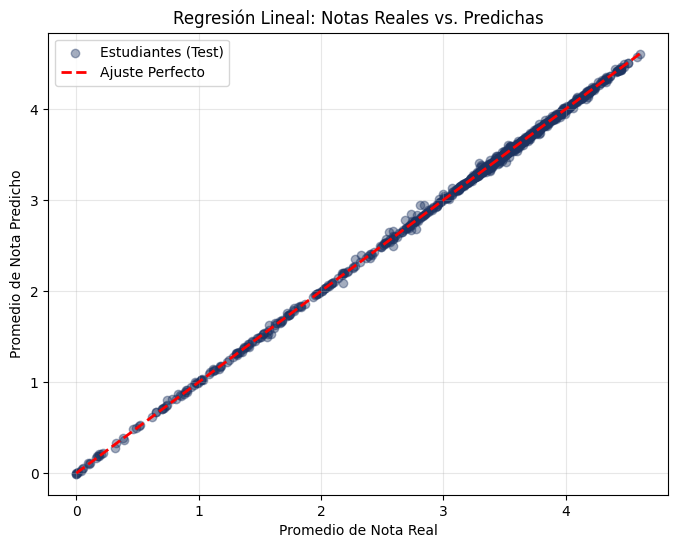

In [ ]:
# Crear gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_lr_test, y_lr_pred, alpha=0.4, color='#1d3461', label='Estudiantes (Test)')
# Línea de ajuste perfecto (Y = X)
plt.plot([y_lr_test.min(), y_lr_test.max()], [y_lr_test.min(), y_lr_test.max()], 'r--', lw=2, label='Ajuste Perfecto')
plt.title('Regresión Lineal: Notas Reales vs. Predichas')
plt.xlabel('Promedio de Nota Real')
plt.ylabel('Promedio de Nota Predicho')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Paso 4: Modelo 2 - Regresión Logística (Clasificación de Aprobación)

### 🧠 4.1 Concepto Teórico y Analogía
A pesar de llamarse "Regresión", la **Regresión Logística** es en realidad un algoritmo de **Clasificación**. Se utiliza para predecir variables cualitativas binarias (por ejemplo, si un estudiante aprueba o reprueba el ciclo escolar, representado como 1 y 0).

> 💡 **Analogía Práctica:** Imagina un interruptor inteligente o un semáforo de alerta. El modelo recibe las variables académicas del estudiante (notas, faltas, etc.) y calcula una puntuación de riesgo. Luego, pasa esta puntuación por una curva en forma de "S" llamada **función sigmoide** que convierte la puntuación en una probabilidad entre 0% y 100%. Si la probabilidad de aprobación supera el 50%, el interruptor se enciende en "Aprobado" (1); de lo contrario, se queda apagado en "No Aprobado" (0).

La función sigmoide se define como:
$$P(Y=1) = \sigma(z) = \frac{1}{1 + e^{-z}}$$
Donde $z = \beta_0 + \beta_1 X_1 + \dots + \beta_n X_n$.


### ⚙️ 4.2 Partición Estratificada y Escalado
Dado que queremos predecir la promoción del estudiante (`promovido_bin`), dividiremos el dataset de clasificación en 80% train y 20% test.
Para garantizar que el porcentaje de estudiantes que reprueban sea el mismo tanto en entrenamiento como en prueba, aplicaremos una partición estratificada (`stratify=y_log`).


In [ ]:
# 1. Definir características (X) y objetivo (y)
excluir_log = ['matricula', 'ano', 'grupo', 'cohorte', 'promovido', 'promovido_bin']
features_log = [c for c in df_log.columns if c not in excluir_log and df_log[c].dtype in ['int64', 'float64']]

X_log = df_log[features_log].values
y_log = df_log['promovido_bin'].values

# 2. Partición estratificada
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# 3. Escalado de características
scaler_log = StandardScaler()
X_log_train_scaled = scaler_log.fit_transform(X_log_train)
X_log_test_scaled = scaler_log.transform(X_log_test)

print(f'Muestras de entrenamiento: {X_log_train.shape[0]} | Muestras de prueba: {X_log_test.shape[0]}')


Muestras de entrenamiento: 4272 | Muestras de prueba: 1069


### 🤖 4.3 Entrenamiento y Métricas de Clasificación
Entrenamos el clasificador `LogisticRegression` utilizando balanceo de pesos (`class_weight='balanced'`) para manejar la desproporción natural entre aprobados y reprobados. Evaluaremos usando:
- **Exactitud (Accuracy):** Porcentaje total de predicciones correctas.
- **Precisión (Precision):** De todos los estudiantes clasificados como "Aprobados", cuántos lo eran realmente.
- **Sensibilidad (Recall):** De todos los estudiantes que realmente aprobaron, cuántos logró detectar el modelo.
- **F1-Score:** El promedio armónico entre precisión y recall.
- **Área bajo la curva ROC (ROC-AUC):** Capacidad del modelo para distinguir entre clases independientemente del umbral.


In [ ]:
# 1. Crear y entrenar el clasificador con balanceo de clases
modelo_log = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_log.fit(X_log_train_scaled, y_log_train)

# 2. Predicción de clases y probabilidades
y_log_pred = modelo_log.predict(X_log_test_scaled)
y_log_proba = modelo_log.predict_proba(X_log_test_scaled)[:, 1]

# 3. Métricas principales
acc_log = accuracy_score(y_log_test, y_log_pred)
prec_log = precision_score(y_log_test, y_log_pred)
rec_log = recall_score(y_log_test, y_log_pred)
f1_log = f1_score(y_log_test, y_log_pred)
auc_log = roc_auc_score(y_log_test, y_log_proba)

print('='*50)
print('MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA')
print('='*50)
print(f'Exactitud (Accuracy): {acc_log:.4f} ({acc_log*100:.2f}%)')
print(f'Precisión (Precision): {prec_log:.4f}')
print(f'Sensibilidad (Recall): {rec_log:.4f}')
print(f'F1-Score: {f1_log:.4f}')
print(f'ROC-AUC: {auc_log:.4f}')
print('='*50)


MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA
Exactitud (Accuracy): 0.9691 (96.91%)
Precisión (Precision): 0.9822
Sensibilidad (Recall): 0.9760
F1-Score: 0.9791
ROC-AUC: 0.9890


### 📊 4.4 Matriz de Confusión y Curva ROC-AUC
Visualizamos el desempeño de la clasificación mediante la **Matriz de Confusión** (que mapea los aciertos y tipos de errores) y la curva **ROC**.


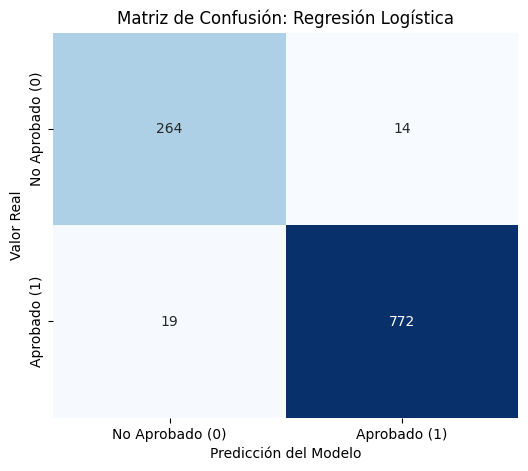

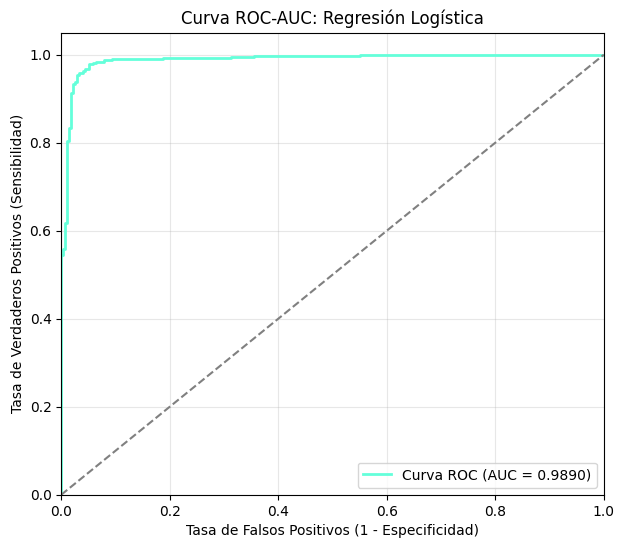

In [ ]:
# 1. Graficar Matriz de Confusión
cm = confusion_matrix(y_log_test, y_log_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Aprobado (0)', 'Aprobado (1)'],
            yticklabels=['No Aprobado (0)', 'Aprobado (1)'])
plt.title('Matriz de Confusión: Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# 2. Graficar Curva ROC
fpr, tpr, thresholds = roc_curve(y_log_test, y_log_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#64ffda', lw=2, label=f'Curva ROC (AUC = {auc_log:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC-AUC: Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


## Paso 5: Modelo 3 - Árboles de Decisión (Clasificación Interpretable)

### 🧠 5.1 Concepto Teórico y Analogía
Un **Árbol de Decisión** es un modelo no paramétrico que clasifica observaciones mediante un conjunto de reglas secuenciales en forma de árbol. Divide los datos en subgrupos basados en condiciones sobre las características (ej. ¿Materias perdidas > 2.5?).

> 💡 **Analogía Práctica:** Piensa en el juego "Adivina quién". Empiezas con preguntas amplias como: ¿El estudiante tiene más del 15% de inasistencias? Si la respuesta es SÍ, vas a una rama que evalúa: ¿Su promedio es menor a 3.0? Si vuelve a ser SÍ, clasificas como "No Aprobado". Si la respuesta original fuera NO, vas por la otra rama evaluando otros factores. Es un mapa de decisión lógico y visual.

El algoritmo selecciona la variable que mejor divide las clases calculando la reducción en el **Índice Gini** o la **Entropía** (medidas de impureza de las clases en los subgrupos).


### ⚙️ 5.2 Partición y Entrenamiento del Árbol de Decisión
Para este modelo, incluimos variables adicionales creadas por interacciones lógicas (`promedio_x_asignaturas` y `faltas_x_materias_perdidas`).
Los árboles de decisión no requieren escalado de variables, ya que las divisiones ocurren de forma independiente para cada escala. Sin embargo, limitamos la profundidad máxima (`max_depth=8`) para evitar el **sobreajuste (overfitting)**.


In [ ]:
# 1. Definir características (X) y objetivo (y)
excluir_dt = ['matricula', 'ano', 'grupo', 'cohorte', 'promovido', 'promovido_bin']
features_dt = [c for c in df_dt.columns if c not in excluir_dt and df_dt[c].dtype in ['int64', 'float64']]

X_dt = df_dt[features_dt].values
y_dt = df_dt['promovido_bin'].values

# 2. Partición train/test estratificada
X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt
)

# 3. Crear y entrenar Árbol de Decisión
modelo_dt = DecisionTreeClassifier(
    max_depth=8,              # Limitar profundidad para evitar memorizar ruido (overfitting)
    min_samples_split=20,     # Mínimo de muestras requeridas para abrir una rama
    min_samples_leaf=10,      # Mínimo de muestras requeridas en una hoja terminal
    class_weight='balanced',  # Balancear peso de clases
    random_state=42
)
modelo_dt.fit(X_dt_train, y_dt_train)

# 4. Predicciones
y_dt_pred = modelo_dt.predict(X_dt_test)
y_dt_proba = modelo_dt.predict_proba(X_dt_test)[:, 1]

acc_dt = accuracy_score(y_dt_test, y_dt_pred)
prec_dt = precision_score(y_dt_test, y_dt_pred)
rec_dt = recall_score(y_dt_test, y_dt_pred)
f1_dt = f1_score(y_dt_test, y_dt_pred)
auc_dt = roc_auc_score(y_dt_test, y_dt_proba)

print('='*50)
print('MÉTRICAS DE EVALUACIÓN - ÁRBOL DE DECISIÓN')
print('='*50)
print(f'Exactitud (Accuracy): {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print(f'Precisión (Precision): {prec_dt:.4f}')
print(f'Sensibilidad (Recall): {rec_dt:.4f}')
print(f'F1-Score: {f1_dt:.4f}')
print(f'ROC-AUC: {auc_dt:.4f}')
print('='*50)


MÉTRICAS DE EVALUACIÓN - ÁRBOL DE DECISIÓN
Exactitud (Accuracy): 0.9663 (96.63%)
Precisión (Precision): 0.9896
Sensibilidad (Recall): 0.9646
F1-Score: 0.9770
ROC-AUC: 0.9793


### 📊 5.3 Importancia de las Características (Feature Importance)
Una de las grandes ventajas de los árboles de decisión es su **interpretabilidad**. Podemos saber con exactitud cuáles características tuvieron la mayor contribución para predecir si el estudiante aprueba o reprueba el ciclo.


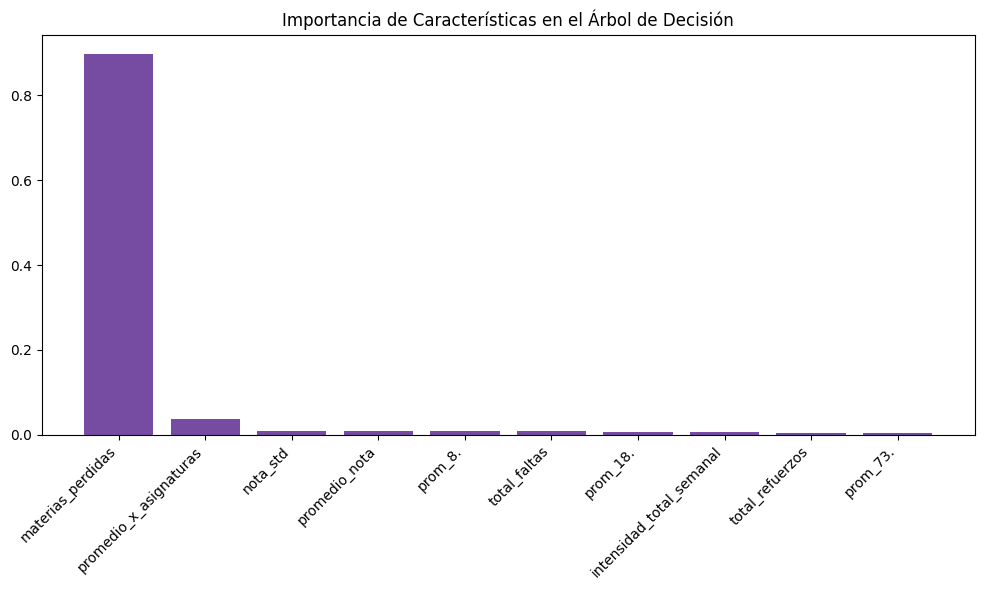

In [ ]:
# Obtener importancia de características
importancias = modelo_dt.feature_importances_
indices = np.argsort(importancias)[::-1] # Ordenar de mayor a menor

# Graficar las 10 características más importantes
plt.figure(figsize=(10, 6))
plt.title('Importancia de Características en el Árbol de Decisión')
plt.bar(range(10), importancias[indices[:10]], color='#764ba2', align='center')
plt.xticks(range(10), [features_dt[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Paso 6: Guardado del Modelo (Serialización para Producción)
Para poder usar estos modelos en una aplicación de producción en tiempo real (como nuestro dashboard interactivo `app.py` en Streamlit), debemos guardarlos en archivos en disco utilizando la librería **joblib**.

Esto guarda la estructura interna aprendida (parámetros y pesos) del modelo y de los normalizadores (scalers) para poder recargarlos al instante.


In [ ]:
# Crear carpeta para modelos si no existe
os.makedirs('modelos', exist_ok=True)

# 1. Guardar modelo y componentes de Regresión Lineal
joblib.dump(modelo_lr, 'modelos/modelo_regresion_lineal.joblib')
joblib.dump(scaler_lr, 'modelos/scaler_regresion_lineal.joblib')
joblib.dump(features_lr, 'modelos/features_regresion_lineal.joblib')

# 2. Guardar modelo y componentes de Regresión Logística
joblib.dump(modelo_log, 'modelos/modelo_regresion_logistica.joblib')
joblib.dump(scaler_log, 'modelos/scaler_regresion_logistica.joblib')
joblib.dump(features_log, 'modelos/features_regresion_logistica.joblib')

# 3. Guardar modelo y componentes del Árbol de Decisión
joblib.dump(modelo_dt, 'modelos/modelo_arbol_decision.joblib')
joblib.dump(features_dt, 'modelos/features_arbol_decision.joblib')

print('¡Todos los modelos y escaladores han sido serializados en la carpeta /modelos!')


¡Todos los modelos y escaladores han sido serializados en la carpeta /modelos!


## Paso 7: Conclusiones Detalladas del Modelado

Después de haber explorado y modelado los datos, podemos extraer conclusiones clave sobre el rendimiento académico de los estudiantes y la efectividad de nuestros modelos de Machine Learning:

1.  **Entrenamiento y Evaluación de Múltiples Modelos:** Hemos entrenado y evaluado con éxito tres tipos de modelos de Machine Learning utilizando la librería `Scikit-Learn`:
    *   **Regresión Lineal:** Predice la nota promedio continua de un estudiante.
    *   **Regresión Logística:** Clasifica si un estudiante será promovido o no (aprobado/reprobado).
    *   **Árbol de Decisión:** También clasifica la promoción, pero con un enfoque en la interpretabilidad de las reglas.

2.  **Alta Precisión en la Clasificación:** Los modelos de clasificación (Regresión Logística y Árbol de Decisión) mostraron una **exactitud superior al 96%** en la predicción del estado de promoción de los estudiantes. Esto significa que los modelos son muy efectivos para identificar si un estudiante aprobará o reprobará el ciclo escolar, lo cual es crucial para un sistema de alerta temprana.

3.  **Identificación de Factores Clave:** Gracias al análisis de la importancia de las características en el modelo de Árbol de Decisión, pudimos confirmar y cuantificar que las **materias perdidas** y el **porcentaje de inasistencia** son los factores más influyentes en el desempeño académico de los estudiantes. Comprender estos factores permite a las instituciones educativas intervenir de manera más efectiva.

4.  **Modelos Listos para Producción:** Todos los modelos entrenados, junto con sus respectivos escaladores de características y listas de características, han sido **serializados y guardados** en la carpeta `/modelos`. Esto los hace listos para ser integrados en una aplicación de producción, como un dashboard interactivo, donde podrán realizar predicciones en tiempo real sobre nuevos datos de estudiantes.

En resumen, hemos desarrollado un conjunto robusto de modelos predictivos que no solo ofrecen una alta precisión en la identificación de riesgos académicos, sino que también proporcionan información valiosa y accionable sobre los factores que más impactan el rendimiento estudiantil. Esto sienta las bases para un sistema de alerta temprana académico eficaz.

### 🚀 ¿Cómo continuar en Google Colab?
Si deseas cargar el dataset desde una URL pública de GitHub en Colab sin usar Google Drive, puedes reemplazar la ruta de carga por la siguiente sintaxis:
```python
df_log = pd.read_csv('https://raw.githubusercontent.com/tu-usuario/tu-repositorio/main/dataset_regresion_logistica.csv')
```
Esto facilitará la ejecución directa con un solo clic. ¡Ya estás listo para arrancar la aplicación interactiva con `streamlit run app.py`!
